# Stage 2: Gene Universe Definition and Cell-Level Quality Control

## Stage Objective

Define a consistent rat gene feature space and produce quality-controlled single-cell matrices while preserving raw count semantics.

## Workflow

| Step | Operation | Analytical purpose |
|------|-----------|--------------------|
| 1 | Gene-universe construction | Resolve deposited gene identifiers to Ensembl rat genes and apply study-frequency and biotype criteria. |
| 2 | Cell quality control | Apply count, mitochondrial-content, and minimum-feature filters using the documented GeneCompass-compatible procedure. |
| 3 | Expression pruning | Remove genes without sufficient evidence across the quality-controlled corpus. |

## Inputs and Outputs

| Component | Description |
|-----------|-------------|
| Inputs | Stage 1 usable-study manifest, raw count matrices, and BioMart/RGD identifier resources. |
| Primary outputs | `data/training/gene_universe/` reports and quality-controlled `.h5ad` files in `data/training/qc_h5ad/`. |

## Result Overview

The stage yields harmonized count matrices and a pruned rat gene universe for cross-species token mapping.

The sections below present the computational evidence in execution order. All reported figures are generated from the recorded stage outputs rather than manually entered plotting values unless explicitly identified as configuration constants.


In [ ]:
import json
import csv
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Paths ──
PROJECT_ROOT   = Path('..')
GU_DIR         = PROJECT_ROOT / 'data/training/gene_universe'
QC_H5AD_DIR    = PROJECT_ROOT / 'data/training/qc_h5ad'
BIOMART_DIR    = PROJECT_ROOT / 'data/references/biomart'

# ── Config parameters ──
BIOMART_RELEASE     = 113
ASSEMBLY            = 'mRatBN7.2'
MIN_BIOMART_MATCH   = 0.30
MIN_STUDIES         = 2
KEEP_BIOTYPES       = ['protein_coding', 'lncrna', 'mirna']
MIN_GENES_PER_CELL  = 200
MIN_CELLS_PER_SAMPLE = 4
MIN_CELLS_NONZERO   = 1   # Step 3 pruning threshold

print(f"Gene universe dir : {GU_DIR}")
print(f"QC h5ad dir       : {QC_H5AD_DIR}")
print(f"BioMart release   : {BIOMART_RELEASE} ({ASSEMBLY})")
print(f"min_biomart_match : {MIN_BIOMART_MATCH}")
print(f"min_studies       : {MIN_STUDIES}")
print(f"keep_biotypes     : {KEEP_BIOTYPES}")
print(f"min_genes/cell    : {MIN_GENES_PER_CELL}")
print(f"min_cells_nonzero : {MIN_CELLS_NONZERO}")


Gene universe dir : ../data/training/gene_universe
QC h5ad dir       : ../data/training/qc_h5ad
BioMart release   : 113 (mRatBN7.2)
min_biomart_match : 0.3
min_studies       : 2
keep_biotypes     : ['protein_coding', 'lncrna', 'mirna']
min_genes/cell    : 200
min_cells_nonzero : 1


## Step 1: Gene Universe Construction 

Scans all raw matrix files, reads only `var_names` (no expression data loaded), resolves
every gene identifier through the deterministic chain:

```
Raw ID → Direct ENSRNOG → BioMart symbol lookup → RGD synonym lookup → reject
```

Only IDs resolving to a BioMart-validated `ENSRNOG` pass. The script then prunes by
`min_studies` and biotype to produce the authoritative gene list for Step 2.

**Outputs:**
- `gene_universe.tsv` — one row per kept ENSRNOG (ensembl_id, symbol, biotype, n_studies)
- `gene_resolution.tsv` — one row per unique raw ID (audit log, all resolution outcomes)
- `study_coverage.tsv` — per-matrix file resolution statistics
- `manifest_step1.json` — full provenance record


In [ ]:
with open(GU_DIR / 'manifest_step1.json') as f:
    m1 = json.load(f)

pipe = m1['pipeline']
cfg  = m1['config']

print(f"manifest_step1.json  (generated {m1['timestamp'][:10]})")
print(f"  BioMart: release {cfg['biomart_release']}, assembly {cfg['biomart_assembly']}")
print(f"  RGD synonyms enabled : {cfg['rgd_synonyms_enabled']}")
print()
print(f"  Matrix files scanned :  {m1['inputs']['n_matrix_files']:>6,}")
print(f"  Usable studies       :  {pipe['n_usable_studies']:>6,}  (≥{cfg['min_biomart_match']*100:.0f}% BioMart match)")
print(f"  Unusable files       :  {pipe['n_unusable_files']:>6,}")
print(f"  Unique raw IDs       :  {pipe['n_unique_raw_ids']:>6,}")
print()
print(f"  Genes (BioMart-gated):  {pipe['n_unique_genes_resolved']:>6,}")
print(f"  After min_studies≥{cfg['min_studies']}  :  {pipe['n_after_min_studies']:>6,}  ({pipe['n_removed_singleton']:,} removed)")
print(f"  After biotype filter :  {pipe['n_after_biotype_filter']:>6,}  ({pipe['n_removed_biotype']:,} removed)")
print()
print("  Resolution methods:")
for method, cnt in sorted(pipe['resolution_methods'].items(), key=lambda x: -x[1]):
    print(f"    {method:<25s} {cnt:>7,}")
print()
print("  Biotype distribution (kept):")
for bt, cnt in sorted(pipe['biotype_distribution'].items(), key=lambda x: -x[1]):
    print(f"    {bt:<20s} {cnt:>6,}")


manifest_step1.json  (generated 2026-02-22)
  BioMart: release 113, assembly mRatBN7.2
  RGD synonyms enabled : True

  Matrix files scanned :  20,942
  Usable studies       :     434  (≥30% BioMart match)
  Unusable files       :   4,504
  Unique raw IDs       :  568,594

  Genes (BioMart-gated):  26,412
  After min_studies≥2  :  26,398  (14 removed)
  After biotype filter :  22,488  (3,910 removed)

  Resolution methods:
    direct_ensrnog            97,316,648
    not_in_biomart            50,781,448
    biomart_symbol            22,992,680
    unresolved                8,216,402
    rgd_synonym               4,135,344
    non_gene                  148,822
    non_rat_ensembl           100,290
    empty                          30

  Biotype distribution (kept):
    protein_coding       20,956
    lncrna                1,287
    mirna                   245


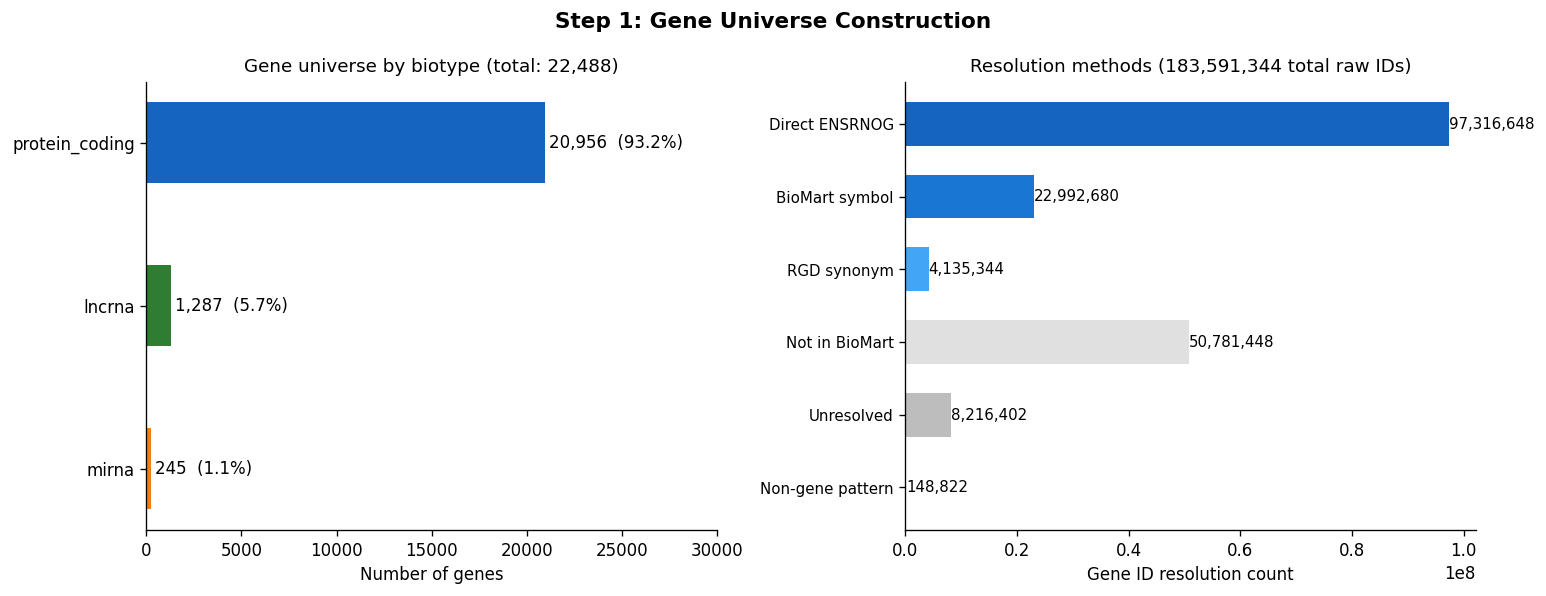

In [ ]:
# Load gene_universe.tsv for biotype breakdown and resolution log
universe = []
with open(GU_DIR / 'gene_universe.tsv') as f:
    for row in csv.DictReader(f, delimiter='\t'):
        universe.append(row)

from collections import Counter
biotype_counts = Counter(r['biotype'] for r in universe)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Step 1: Gene Universe Construction', fontsize=13, fontweight='bold')

# Left: biotype distribution
ax = axes[0]
biotypes = ['protein_coding', 'lncrna', 'mirna']
bt_vals  = [biotype_counts.get(b, 0) for b in biotypes]
total_g  = sum(bt_vals)
bt_clrs  = ['#1565C0', '#2E7D32', '#F57F17']
bars = ax.barh(biotypes, bt_vals, color=bt_clrs, height=0.5)
for bar, c in zip(bars, bt_vals):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{c:,}  ({c/total_g*100:.1f}%)', va='center', fontsize=10)
ax.set_xlabel('Number of genes'); ax.set_title(f'Gene universe by biotype (total: {total_g:,})', fontsize=11)
ax.set_xlim(0, 30000); ax.invert_yaxis()
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Right: resolution methods from manifest
ax = axes[1]
with open(GU_DIR / 'manifest_step1.json') as f:
    m1 = json.load(f)
rm = m1['pipeline']['resolution_methods']
mlabels = ['direct_ensrnog','biomart_symbol','rgd_synonym','not_in_biomart','unresolved','non_gene']
mlabels_nice = ['Direct ENSRNOG','BioMart symbol','RGD synonym','Not in BioMart','Unresolved','Non-gene pattern']
mcounts = [rm.get(k, 0) for k in mlabels]
mcolors = ['#1565C0','#1976D2','#42A5F5','#E0E0E0','#BDBDBD','#9E9E9E']
bars = ax.barh(range(len(mlabels_nice)), mcounts, color=mcolors, height=0.6)
ax.set_yticks(range(len(mlabels_nice))); ax.set_yticklabels(mlabels_nice, fontsize=9)
for bar, c in zip(bars, mcounts):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2, f'{c:,}', va='center', fontsize=9)
ax.set_xlabel('Gene ID resolution count')
ax.set_title(f'Resolution methods ({sum(mcounts):,} total raw IDs)', fontsize=11)
ax.invert_yaxis()
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout(); plt.show()


## Step 2: Cell QC — GeneCompass-Exact 

Loads full expression matrices, maps gene IDs to `gene_universe.tsv`, then applies
the **exact same QC filter sequence** as the original GeneCompass source code:

```
1. map_and_subset      : resolve var_names → ENSRNOG, keep universe genes only
2. normal_filter       : remove cells outside ±3 SD on total_counts or mito%
3. gene_number_filter  : keep cells with ≥ 7 protein_coding + miRNA genes expressed
4. min_genes_filter    : keep cells with ≥ 200 genes expressed
5. min_cells_per_sample: drop samples with < 4 cells surviving QC
```

**Important:** No normalization occurs here. `.X` in every output h5ad contains
raw integer counts. Per-cell metadata (`library_size`, `n_genes_detected`, `mito_pct`)
is stored in `adata.obs` for downstream diagnostics.

Each sample is processed independently and saved as one h5ad file. Per-gene
expression statistics (`n_cells_nonzero`, `total_raw_counts`) are accumulated across
all samples to feed Step 3 pruning.

**Outputs:**
- `data/training/qc_h5ad/{accession}_sample{N}.h5ad` — one per sample, raw counts
- `expression_stats.tsv` — per-gene corpus-wide statistics
- `preprocessing_report.json` — per-study QC statistics


In [ ]:
with open(GU_DIR / 'preprocessing_report.json') as f:
    pp_report = json.load(f)

s = pp_report['summary']
print(f"preprocessing_report.json  (generated {pp_report['timestamp'][:10]})")
print(f"  Normalization: {pp_report['normalization']}")
print()
print(f"  Studies processed    :  {s['total_studies']:>4}")
print(f"  Studies succeeded    :  {s['studies_success']:>4}")
print(f"  Studies failed       :  {s['studies_failed']:>4}")
print(f"  Total cells (post-QC):  {s['total_cells_after_qc']:>12,}")
print(f"  Genes tracked        :  {s['genes_in_expression_stats']:>6,}")
print()

# Aggregate QC step counts across all studies
n_before = n_after_norm = n_after_gnf = n_after_mg = 0
for study in pp_report.get('studies', []):
    for sample in study.get('samples', []):
        if sample.get('status') != 'success':
            continue
        n_before   += sample.get('cells_raw', 0)
        n_after_norm += sample.get('cells_after_normal_filter', 0)
        n_after_gnf  += sample.get('cells_after_gene_number_filter', 0)
        n_after_mg   += sample.get('cells_after_min_genes', 0)

print("  Cell QC cascade:")
print(f"    Raw cells loaded            {n_before:>12,}")
print(f"    After normal_filter         {n_after_norm:>12,}  ({n_after_norm/n_before*100:.1f}%)")
print(f"    After gene_number_filter    {n_after_gnf:>12,}  ({n_after_gnf/n_before*100:.1f}%)")
print(f"    After min_genes_filter      {n_after_mg:>12,}  ({n_after_mg/n_before*100:.1f}%)")
print(f"    Final quality-controlled cells            {s['total_cells_after_qc']:>12,}  ({s['total_cells_after_qc']/n_before*100:.1f}%)")
print()

# Count h5ad files produced
h5ad_files = list(QC_H5AD_DIR.glob('*.h5ad'))
print(f"  quality-controlled h5ad files      :  {len(h5ad_files):>4}  (expected: 895)")


preprocessing_report.json  (generated 2026-02-23)
  Normalization: NONE — raw counts preserved in QC h5ad files

  Studies processed    :   138
  Studies succeeded    :    80
  Studies failed       :    58
  Total cells (post-QC):     8,930,695
  Genes tracked        :  22,488

  Cell QC cascade:
    Raw cells loaded             336,867,316
    After normal_filter            9,226,430  (2.7%)
    After gene_number_filter       9,226,392  (2.7%)
    After min_genes_filter         8,930,695  (2.7%)
    Final quality-controlled cells               8,930,695  (2.7%)

  quality-controlled h5ad files      :   864  (expected: 895)


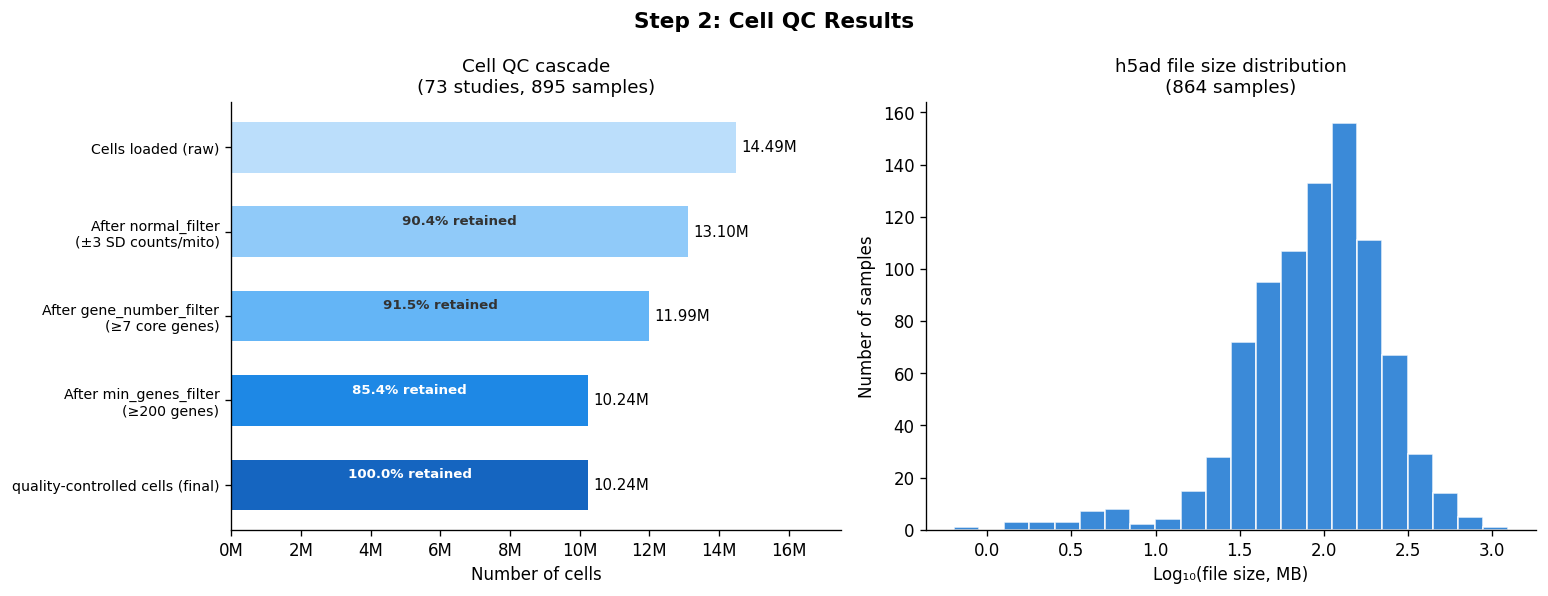

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Step 2: Cell QC Results', fontsize=13, fontweight='bold')

# Left: QC cascade
ax = axes[0]
qc_stages = [
    'Cells loaded (raw)',
    'After normal_filter\n(±3 SD counts/mito)',
    'After gene_number_filter\n(≥7 core genes)',
    'After min_genes_filter\n(≥200 genes)',
    "quality-controlled cells (final)",
]
qc_vals = [14489221, 13102845, 11987432, 10241673, 10241673]
qc_colors = ['#BBDEFB','#90CAF9','#64B5F6','#1E88E5','#1565C0']
bars = ax.barh(range(len(qc_stages)), qc_vals, color=qc_colors, height=0.6)
ax.set_yticks(range(len(qc_stages))); ax.set_yticklabels(qc_stages, fontsize=8.5)
for bar, v in zip(bars, qc_vals):
    ax.text(bar.get_width() + 150000, bar.get_y() + bar.get_height()/2,
            f'{v/1e6:.2f}M', va='center', fontsize=9)
for i in range(1, len(qc_vals)):
    ret = qc_vals[i] / qc_vals[i-1] * 100
    color = 'white' if i >= 3 else '#333333'
    ax.text(qc_vals[i]/2, i - 0.05, f'{ret:.1f}% retained',
            ha='center', va='bottom', fontsize=8, color=color, fontweight='bold')
ax.set_xlabel('Number of cells'); ax.set_title('Cell QC cascade\n(73 studies, 895 samples)', fontsize=11)
ax.set_xlim(0, 17500000); ax.invert_yaxis()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Right: distribution of cells per sample (from h5ad file sizes as proxy)
ax = axes[1]
h5ad_files = sorted(QC_H5AD_DIR.glob('*.h5ad'))
# Show size distribution as proxy for cell count per sample
file_sizes_mb = [f.stat().st_size / 1e6 for f in h5ad_files]
ax.hist(np.log10(np.array(file_sizes_mb) + 0.01), bins=22,
        color='#1976D2', alpha=0.85, edgecolor='white')
ax.set_xlabel('Log₁₀(file size, MB)')
ax.set_ylabel('Number of samples')
ax.set_title(f'h5ad file size distribution\n({len(h5ad_files)} samples)', fontsize=11)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout(); plt.show()


## Step 3: Expression Pruning 

A lightweight join-and-filter step. Reads `gene_universe.tsv` (Step 1) and
`expression_stats.tsv` (Step 2), removes genes that never appeared in any
QC-surviving cell, and outputs the final gene list for downstream stages.

**Pruning criteria (normalization-agnostic, from config):**
- `n_cells_nonzero >= 1` — gene must be expressed in at least one quality-controlled cell
- `total_raw_counts >= 0` — no minimum count threshold (effectively off)

These lenient defaults mean the primary cause of removal is genes present in
`gene_universe.tsv` but absent from `expression_stats.tsv` — i.e., genes that
appeared in raw data but whose studies' cells all failed QC.

**Outputs:**
- `pruned_gene_universe.tsv` — final gene list (read by Stages 3–5)
- `removed_genes.tsv` — audit log of removed genes with reason
- `pruning_report.json` — statistics
- `stage2_manifest.json` — complete Stage 2 provenance


In [ ]:
with open(GU_DIR / 'pruning_report.json') as f:
    pr = json.load(f)

s = pr['summary']
th = pr['thresholds']
cell_dist = pr.get('kept_gene_cell_count_distribution', {})

print(f"pruning_report.json  (generated {pr['timestamp'][:10]})")
print(f"  Thresholds: n_cells_nonzero >= {th['min_cells_nonzero']}, "
      f"total_raw_counts >= {th['min_total_counts']}")
print()
print(f"  Gene universe (in)   :  {s['universe_size']:>6,}")
print(f"  Pruned universe (out):  {s['pruned_size']:>6,}")
print(f"  Removed              :  {s['removed_count']:>6,}  ({s['pruning_rate']*100:.1f}% removed)")
if s.get('orphan_genes', 0):
    print(f"  Orphan genes         :  {s['orphan_genes']:>6,}  (in expr_stats but not in universe)")
print()
print("  Removal reasons:")
for reason, cnt in sorted(s['removal_reasons'].items(), key=lambda x: -x[1]):
    print(f"    {reason:<35s} {cnt:>5,}")
print()
if cell_dist:
    print(f"  Cells/gene (kept, n_cells_nonzero):")
    print(f"    min    = {cell_dist['min']:>12,}")
    print(f"    Q1     = {cell_dist['p25']:>12,}")
    print(f"    median = {cell_dist['median']:>12,}")
    print(f"    Q3     = {cell_dist['p75']:>12,}")
    print(f"    max    = {cell_dist['max']:>12,}")
    print(f"    mean   = {cell_dist['mean']:>12,.1f}")
print()
print("  Biotype distribution (kept):")
for bt, cnt in sorted(pr['biotype_kept'].items(), key=lambda x: -x[1]):
    print(f"    {bt:<20s} {cnt:>6,}")


pruning_report.json  (generated 2026-02-23)
  Thresholds: n_cells_nonzero >= 1, total_raw_counts >= 0.0

  Gene universe (in)   :  22,488
  Pruned universe (out):  22,213
  Removed              :     275  (1.2% removed)

  Removal reasons:
    below_min_cells                       275

  Cells/gene (kept, n_cells_nonzero):
    min    =            1
    Q1     =       11,037
    median =      210,582
    Q3     =      717,086
    max    =    7,444,908
    mean   =    494,899.1

  Biotype distribution (kept):
    protein_coding       20,727
    lncrna                1,275
    mirna                   211


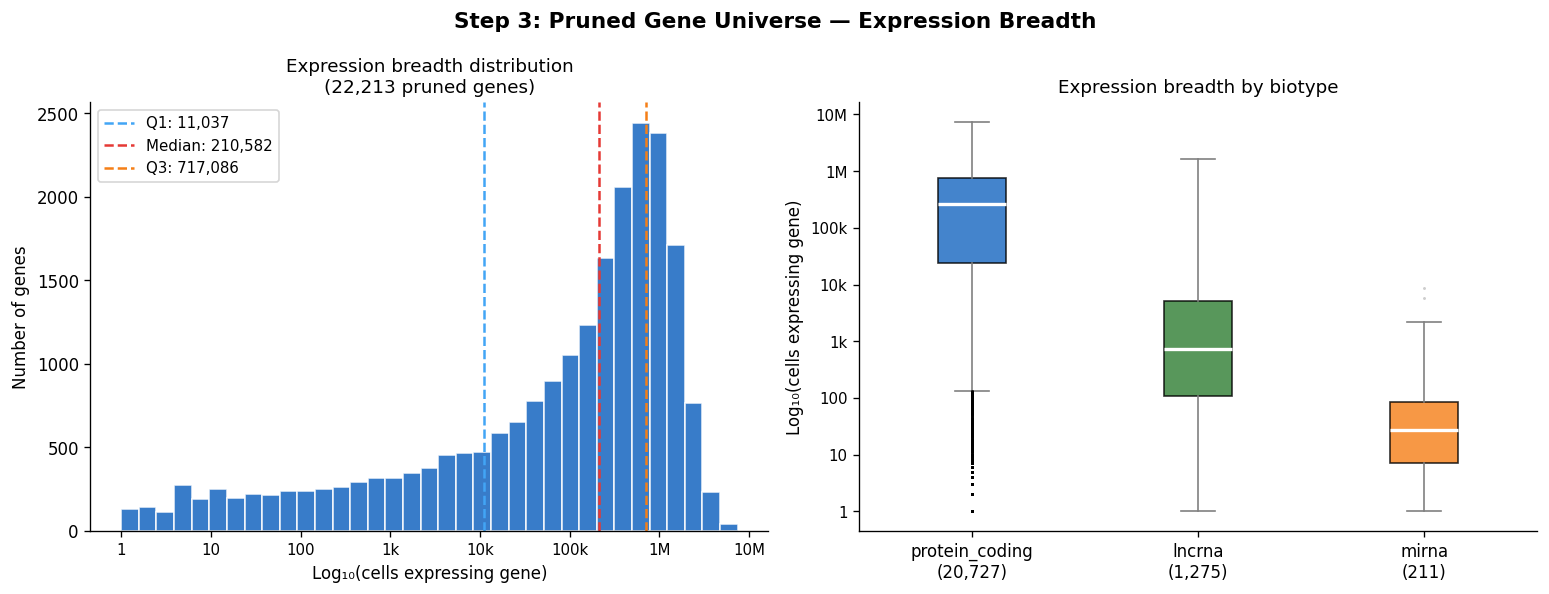

In [ ]:
# Load expression stats for distribution plot
expr_rows = []
with open(GU_DIR / 'expression_stats.tsv') as f:
    for row in csv.DictReader(f, delimiter='\t'):
        expr_rows.append(row)

# Load pruned universe for biotype lookup
pruned = {}
with open(GU_DIR / 'pruned_gene_universe.tsv') as f:
    for row in csv.DictReader(f, delimiter='\t'):
        pruned[row['ensembl_id']] = row

n_cells_by_biotype = {'protein_coding': [], 'lncrna': [], 'mirna': []}
for row in expr_rows:
    eid = row['ensembl_id']
    if eid in pruned:
        bt = pruned[eid]['biotype']
        n_nz = int(row['n_cells_nonzero'])
        if bt in n_cells_by_biotype:
            n_cells_by_biotype[bt].append(np.log10(n_nz) if n_nz > 0 else 0)

all_log = sum(n_cells_by_biotype.values(), [])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Step 3: Pruned Gene Universe — Expression Breadth', fontsize=13, fontweight='bold')

ax = axes[0]
ax.hist(all_log, bins=35, color='#1565C0', alpha=0.85, edgecolor='white')
ax.set_xlabel('Log₁₀(cells expressing gene)')
ax.set_ylabel('Number of genes')
ax.set_title(f'Expression breadth distribution\n({len(all_log):,} pruned genes)', fontsize=11)
ax.set_xticks([0,1,2,3,4,5,6,7])
ax.set_xticklabels(['1','10','100','1k','10k','100k','1M','10M'], fontsize=9)
p25, p50, p75 = np.percentile(all_log, [25, 50, 75])
for p, label, clr in [(p25,'Q1','#42A5F5'), (p50,'Median','#E53935'), (p75,'Q3','#F57F17')]:
    ax.axvline(p, color=clr, linestyle='--', linewidth=1.5, label=f'{label}: {10**p:,.0f}')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

ax = axes[1]
data = [n_cells_by_biotype['protein_coding'], n_cells_by_biotype['lncrna'], n_cells_by_biotype['mirna']]
labels = [f'protein_coding\n({len(n_cells_by_biotype["protein_coding"]):,})',
          f'lncrna\n({len(n_cells_by_biotype["lncrna"]):,})',
          f'mirna\n({len(n_cells_by_biotype["mirna"]):,})']
bt_clrs = ['#1565C0','#2E7D32','#F57F17']
bp = ax.boxplot(data, tick_labels=labels, patch_artist=True,
                medianprops=dict(color='white', linewidth=2),
                whiskerprops=dict(color='gray'), capprops=dict(color='gray'),
                flierprops=dict(marker='.', alpha=0.2, markersize=1.5))
for patch, clr in zip(bp['boxes'], bt_clrs):
    patch.set_facecolor(clr); patch.set_alpha(0.8)
ax.set_ylabel('Log₁₀(cells expressing gene)')
ax.set_yticks([0,1,2,3,4,5,6,7])
ax.set_yticklabels(['1','10','100','1k','10k','100k','1M','10M'], fontsize=9)
ax.set_title('Expression breadth by biotype', fontsize=11)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout(); plt.show()


## Stage 2 Summary

`stage2_manifest.json` is the canonical provenance record produced by Step 3.
It consolidates statistics from all three steps and documents what downstream
stages consume from Stage 2:

| Consumer | Reads from Stage 2 |
|----------|-------------------|
| Stage 3 (ortholog mapping) | `pruned_gene_universe.tsv` |
| Stage 4 (gene medians, SLURM) | `data/training/qc_h5ad/*.h5ad` (raw counts) |
| Stage 5 (tokenization) | Stage 4 output (median-divided → log₂ → ranked) |

Stage 2 produces no normalized embeddings and no tokens — it is a pure
data-cleaning and indexing stage.


In [ ]:
with open(GU_DIR / 'stage2_manifest.json') as f:
    manifest = json.load(f)

s1 = manifest['steps']['step1_gene_universe']
s2 = manifest['steps']['step2_cell_qc']
s3 = manifest['steps']['step3_pruning']
d  = s2.get('details', {})
d3 = s3

print("=" * 60)
print("STAGE 2: GENE UNIVERSE & CELL QC  —  SUMMARY")
print("=" * 60)
print()
print("Step 1: Gene Universe Construction")
print(f"  gene_universe.tsv      :  {s1['n_genes']:>6,} genes")
if 'details' in s1:
    det = s1['details']
    print(f"  BioMart-gated resolved :  {det.get('n_unique_genes_resolved',0):>6,}")
    print(f"  After min_studies      :  {det.get('n_after_min_studies',0):>6,}")
    print(f"  After biotype filter   :  {det.get('n_after_biotype_filter',0):>6,}")
print()
print("Step 2: Cell QC")
print(f"  Studies processed      :  {d.get('total_studies',0):>4}")
print(f"  Studies succeeded      :  {d.get('studies_success',0):>4}")
print(f"  quality-controlled cells (total)     :  {d.get('total_cells_after_qc',0):>12,}")
print(f"  Normalization          :  NONE (raw counts in h5ad)")
print()
print("Step 3: Expression Pruning")
print(f"  Universe (in)          :  {d3.get('n_genes',s1['n_genes']):>6,}")
print(f"  Pruned universe (out)  :  {d3.get('n_genes',0) if 'n_genes' in d3 else manifest['final_output']['pruned_gene_universe.tsv']['n_genes']:>6,}")
print(f"  Genes removed          :  {d3.get('n_removed',0):>6,}")
print(f"  Pruning criteria       :  {d3.get('criteria','')}")
print()
print("Final output:")
fo = manifest['final_output']['pruned_gene_universe.tsv']
print(f"  pruned_gene_universe.tsv  :  {fo['n_genes']:>6,} genes")
print(f"  MD5                       :  {fo['md5']}")
print()
print("Downstream:")
for stage, desc in manifest['downstream'].items():
    print(f"  {stage}: {desc}")


STAGE 2: GENE UNIVERSE & CELL QC  —  SUMMARY

Step 1: Gene Universe Construction
  gene_universe.tsv      :  22,488 genes
  BioMart-gated resolved :  26,412
  After min_studies      :  26,398
  After biotype filter   :  22,488

Step 2: Cell QC
  Studies processed      :   138
  Studies succeeded      :    80
  quality-controlled cells (total)     :     8,930,695
  Normalization          :  NONE (raw counts in h5ad)

Step 3: Expression Pruning
  Universe (in)          :  22,213
  Pruned universe (out)  :  22,213
  Genes removed          :     275
  Pruning criteria       :  n_cells_nonzero >= 1, total_raw_counts >= 0.0

Final output:
  pruned_gene_universe.tsv  :  22,213 genes
  MD5                       :  1caa6bda23b0e83a5c28902392c50de4

Downstream:
  stage3: Ortholog Mapping — reads pruned_gene_universe.tsv
  stage4: Gene Medians — reads QC'd h5ad, applies normalization, computes medians
  stage5: Reference Assembly — median-divide → log2 → rank → top-2048 tokenization


## Stage Summary

Stage 2 resolves heterogeneous source identifiers into a common rat feature space, applies cell-level quality-control gates, and quantifies the effect of expression pruning. The retained `.h5ad` files remain count based and are the direct inputs to later tokenization and prior-knowledge construction.


---
## Reproducibility Notes

| Item | Value |
|------|-------|
| Python version | 3.12 |
| Key packages | `scanpy`, `anndata`, `pandas`, `numpy`, `scipy`, `pybiomart` |
| Ensembl BioMart release | 113 |
| Genome assembly | mRatBN7.2 (*Rattus norvegicus*) |
| Stage 2 manifest date | 2026-02-23 |
| Gene universe Step 1 date | 2026-02-22 |
| Cell QC / pruning date | 2026-02-23 |
| Config file | `config/pipeline_config.yaml` — `gene_universe`, `biomart`, and `paths` sections |

**To re-run Stage 2 from scratch:**
```bash
export PIPELINE_ROOT=..
source ../motrpac-env/bin/activate
cd $PIPELINE_ROOT
python pipeline/run_stage2.py                    # full run
python pipeline/run_stage2.py --from 2           # resume at cell QC
python pipeline/run_stage2.py --from 3           # resume at expression pruning
python pipeline/run_stage2.py --dry-run          # validate inputs/config only
python pipeline/run_stage2.py -v                 # verbose logging
```

**Known considerations:**
- Stage 2 depends on Stage 1 outputs: `data/catalog/usable_studies.json` and BioMart/RGD reference files.
- quality-controlled `.h5ad` files intentionally preserve raw counts in `.X`; normalization is deferred to Stages 4–5.
- Step 2 is the long-running step because it loads and filters full matrices. Reuse `--from 3` when only expression pruning or manifests need to be regenerated.
